# Besoin Client 1 – Comparaison d'algorithmes de Clustering
**Variables :** `haut_tot`, `haut_tronc`, `tronc_diam`  
**Algorithmes testés :** K-Means, Agglomerative Clustering (Ward), Mini-Batch K-Means  
**Objectif :** Comparer les performances et choisir le meilleur modèle à sauvegarder.

## 1. Imports et chargement des données

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import plotly.graph_objects as go
import plotly.express as px

from ipywidgets import interact, IntSlider
import ipywidgets as widgets

In [48]:
from google.colab import drive
drive.mount('/content/drive')

drive_folder_path = '/content/drive/MyDrive/Projet_base_de_donnée/Projet_BDD-IA-WEB/'
df = pd.read_csv(f'{drive_folder_path}Patrimoine_Arboré_data_clean.csv', encoding='utf-8-sig')

print(f"Dimensions : {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensions : (11418, 23)


,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,fk_port,fk_pied,...,fk_prec_estim,clc_nbr_diag,fk_nomtech,villeca,nomfrancais,nomlatin,feuillage,remarquable,Longitude,Latitude
0,Quartier du Centre-Ville,Boulevard Richelieu,24,10.354698,2.883738,0.957527,1,NaN,NaN,NaN,...,0.0,0.0,RAS,VILLE,RAS,RAS,NaN,0,3.282540,49.850458
1,Quartier du Centre-Ville,Boulevard Léon Blum,24,10.354698,2.883738,0.957527,1,NaN,NaN,NaN,...,0.0,0.0,RAS,VILLE,RAS,RAS,NaN,0,3.290521,49.840654
2,Quartier du Centre-Ville,Boulevard Léon Blum,53,10.354698,2.883738,0.957527,1,NaN,NaN,NaN,...,0.0,0.0,RAS,VILLE,RAS,RAS,NaN,0,3.290460,49.840756
3,Quartier du Centre-Ville,Boulevard Léon Blum,54,10.354698,2.883738,0.957527,1,NaN,NaN,NaN,...,0.0,0.0,RAS,VILLE,RAS,RAS,NaN,0,3.290568,49.840783
4,Quartier du Centre-Ville,Boulevard Léon Blum,63,10.354698,2.883738,0.957527,1,NaN,NaN,NaN,...,0.0,0.0,RAS,VILLE,RAS,RAS,NaN,0,3.293178,49.841441


## 2. Préparation des données

In [49]:
features = ['haut_tot', 'haut_tronc', 'tronc_diam']

df_cluster = df[features + ['Latitude', 'Longitude']].copy().dropna(subset=features)
total_initial = len(df)
total_apres   = len(df_cluster)
supprimes     = total_initial - total_apres

print(f"Arbres initiaux          : {total_initial}")
print(f"Arbres après nettoyage   : {total_apres}")
print(f"Arbres supprimés (NaN)   : {supprimes}")
print(f"Soit {supprimes/total_initial*100:.1f}% des données supprimées")
print(f"\nhaut_tot   - NaN initiaux : {df['haut_tot'].isna().sum()}")
print(f"haut_tronc - NaN initiaux : {df['haut_tronc'].isna().sum()}")
print(f"tronc_diam - NaN initiaux : {df['tronc_diam'].isna().sum()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# Sauvegarde du scaler (unique, partagé par tous les modèles)
joblib.dump(scaler, f'{drive_folder_path}scaler_clustering.pkl')
print("Scaler sauvegardé.")

Arbres initiaux          : 11418
Arbres après nettoyage   : 11418
Arbres supprimés (NaN)   : 0
Soit 0.0% des données supprimées

haut_tot   - NaN initiaux : 0
haut_tronc - NaN initiaux : 0
tronc_diam - NaN initiaux : 0
Scaler sauvegardé.


In [50]:
from sklearn.model_selection import train_test_split

# 80% entraînement, 20% test
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]} arbres")
print(f"Taille test  : {X_test.shape[0]} arbres")

Taille train : 9134 arbres
Taille test  : 2284 arbres


## 3. Méthode du coude – Trouver le k optimal (K-Means)

La méthode du coude trace l'inertie en fonction de k. On cherche le point où la diminution devient marginale.

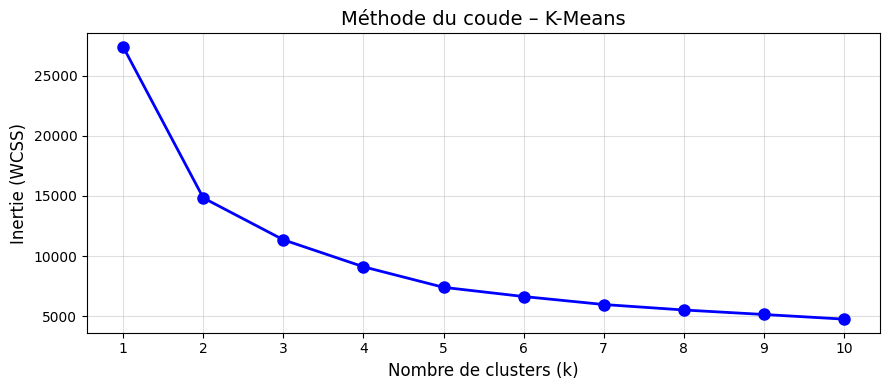

In [51]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_train)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie (WCSS)', fontsize=12)
plt.title('Méthode du coude – K-Means', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{drive_folder_path}elbow_method.png', dpi=150)
plt.show()

In [52]:
results = []
K_eval = range(2, 7)

for k in K_eval:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    sil   = silhouette_score(X_scaled, labels)
    ch    = calinski_harabasz_score(X_scaled, labels)
    db    = davies_bouldin_score(X_scaled, labels)

    results.append({'k': k, 'Silhouette ↑': round(sil, 4),
                    'Calinski-Harabasz ↑': round(ch, 2),
                    'Davies-Bouldin ↓': round(db, 4)})

df_metrics = pd.DataFrame(results).set_index('k')
df_metrics

,Silhouette ↑,Calinski-Harabasz ↑,Davies-Bouldin ↓
k,,,
2,0.4745,9604.12,0.9423
3,0.4197,8065.97,1.0888
4,0.3516,7683.24,1.0553
5,0.3668,7680.26,1.0184
6,0.3449,7133.28,1.0445


In [53]:
# K-optimal observé : 3
K_OPTIMAL = 3
print(f"K optimal retenu : {K_OPTIMAL}")

K optimal retenu : 3


## 4. Entraînement des 3 algorithmes

### Pourquoi ces 3 algorithmes ?
- **K-Means** : référence, rapide, clusters sphériques équilibrés, k imposé par l'utilisateur
- **Mini-Batch K-Means** : variante de K-Means plus rapide sur gros volumes (traite des sous-ensembles), légèrement moins précis mais très scalable
- **Agglomerative Clustering (Ward)** : approche hiérarchique ascendante, ne suppose pas de forme sphérique, plus flexible mais plus lent et **non transductif** (ne prédit pas directement sur de nouvelles données)

In [54]:
# Définition des algorithmes à comparer
algorithms = {
    'K-Means': KMeans(
        n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42
    ),
    'Mini-Batch K-Means': MiniBatchKMeans(
        n_clusters=K_OPTIMAL, init='k-means++', n_init=10,
        batch_size=1024, random_state=42
    ),
    'Agglomerative (Ward)': AgglomerativeClustering(
        n_clusters=K_OPTIMAL, linkage='ward'
    ),
}

results = {}

for name, algo in algorithms.items():
    start = time.time()
    labels = algo.fit_predict(X_scaled)
    elapsed = time.time() - start

    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)

    results[name] = {
        'labels': labels,
        'Silhouette ↑': round(sil, 4),
        'Calinski-Harabasz ↑': round(ch, 2),
        'Davies-Bouldin ↓': round(db, 4),
        'Temps (s)': round(elapsed, 3)
    }
    print(f"{name:25s} | Silhouette={sil:.4f} | CH={ch:.1f} | DB={db:.4f} | {elapsed:.3f}s")

K-Means                   | Silhouette=0.4197 | CH=8066.0 | DB=1.0888 | 0.313s
Mini-Batch K-Means        | Silhouette=0.3390 | CH=7659.4 | DB=1.0893 | 0.020s
Agglomerative (Ward)      | Silhouette=0.3589 | CH=7493.3 | DB=1.2185 | 7.114s


## 5. Tableau de comparaison des performances

In [55]:
df_results = pd.DataFrame({
    name: {
        'Silhouette ↑': v['Silhouette ↑'],
        'Calinski-Harabasz ↑': v['Calinski-Harabasz ↑'],
        'Davies-Bouldin ↓': v['Davies-Bouldin ↓'],
        'Temps (s)': v['Temps (s)']
    }
    for name, v in results.items()
}).T

print("=== Tableau de comparaison des algorithmes ===")
print(df_results.to_string())
print("\nInterprétation :")
print("  Silhouette    : proche de 1 = clusters bien séparés et denses")
print("  Calinski-Harabasz : plus élevé = meilleure séparation inter-cluster")
print("  Davies-Bouldin: proche de 0 = clusters compacts et bien séparés")
print("  Temps         : important pour le passage à l'échelle")

=== Tableau de comparaison des algorithmes ===
                      Silhouette ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓  Temps (s)
K-Means                     0.4197              8065.97            1.0888      0.313
Mini-Batch K-Means          0.3390              7659.43            1.0893      0.020
Agglomerative (Ward)        0.3589              7493.28            1.2185      7.114

Interprétation :
  Silhouette    : proche de 1 = clusters bien séparés et denses
  Calinski-Harabasz : plus élevé = meilleure séparation inter-cluster
  Davies-Bouldin: proche de 0 = clusters compacts et bien séparés
  Temps         : important pour le passage à l'échelle


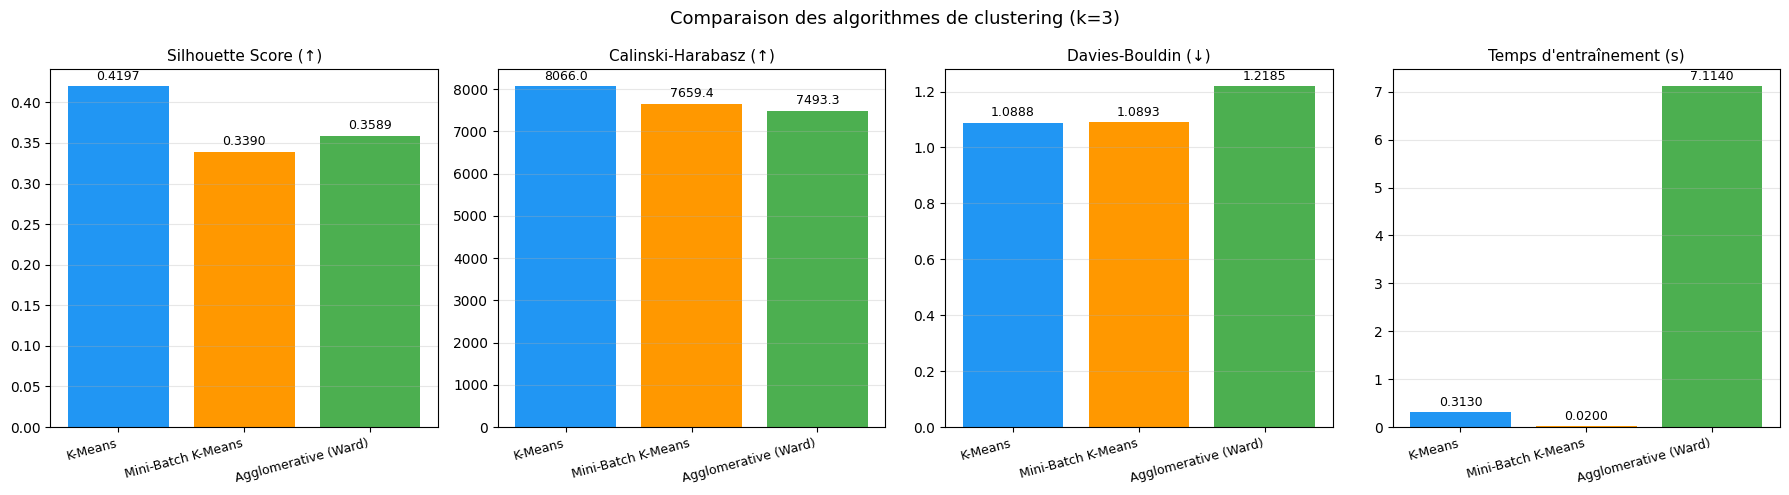

In [56]:
# Visualisation comparative des métriques
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
algo_names = list(results.keys())
colors = ['#2196F3', '#FF9800', '#4CAF50']

metrics = ['Silhouette ↑', 'Calinski-Harabasz ↑', 'Davies-Bouldin ↓', 'Temps (s)']
titles  = ['Silhouette Score (↑)', 'Calinski-Harabasz (↑)', 'Davies-Bouldin (↓)', 'Temps d\'entraînement (s)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [results[a][metric] for a in algo_names]
    bars = axes[i].bar(algo_names, vals, color=colors)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xticklabels(algo_names, rotation=15, ha='right', fontsize=9)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                     f'{val:.4f}' if metric != 'Calinski-Harabasz ↑' else f'{val:.1f}',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Comparaison des algorithmes de clustering (k={K_OPTIMAL})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{drive_folder_path}comparaison_algos.png', dpi=150)
plt.show()

## 6. Visualisation des clusters côte à côte

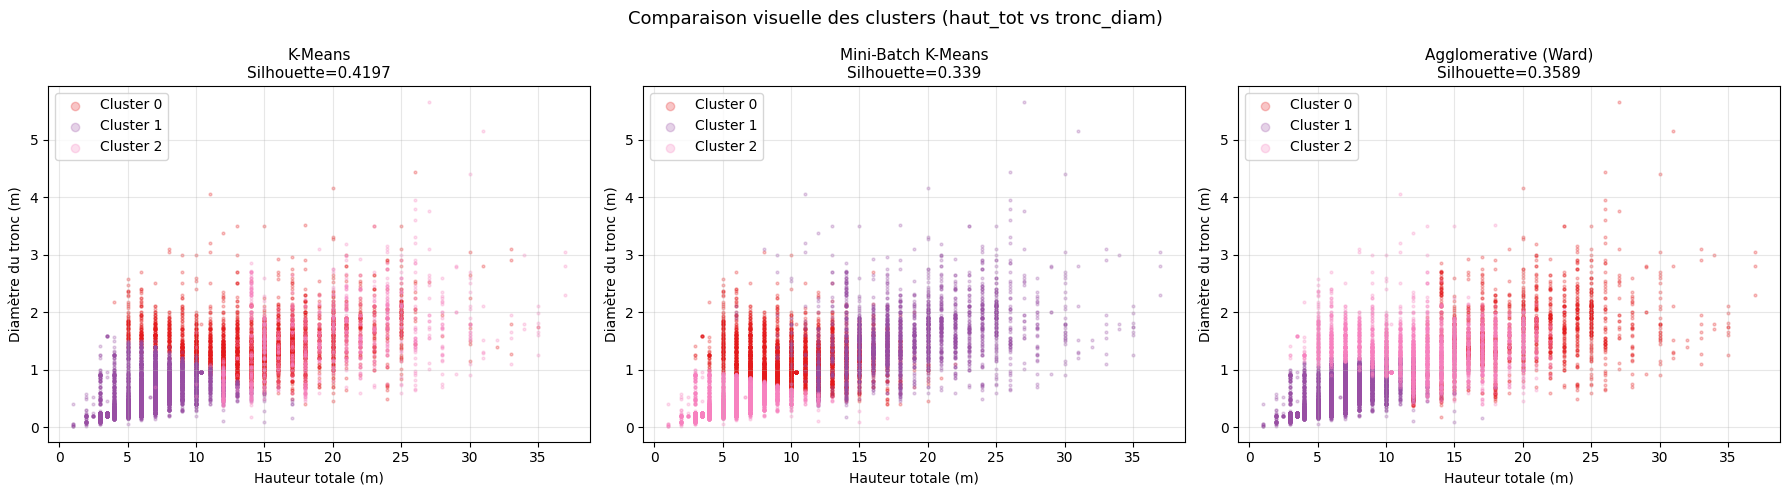

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = plt.cm.Set1(np.linspace(0, 0.8, K_OPTIMAL))

for ax, (name, data) in zip(axes, results.items()):
    labels = data['labels']
    for cluster_id in range(K_OPTIMAL):
        mask = labels == cluster_id
        ax.scatter(
            df_cluster.loc[df_cluster.index[mask], 'haut_tot'],
            df_cluster.loc[df_cluster.index[mask], 'tronc_diam'],
            alpha=0.25, s=4, color=palette[cluster_id], label=f'Cluster {cluster_id}'
        )
    ax.set_title(f'{name}\nSilhouette={data["Silhouette ↑"]}', fontsize=11)
    ax.set_xlabel('Hauteur totale (m)')
    ax.set_ylabel('Diamètre du tronc (m)')
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison visuelle des clusters (haut_tot vs tronc_diam)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{drive_folder_path}clusters_comparaison_visuelle.png', dpi=150)
plt.show()

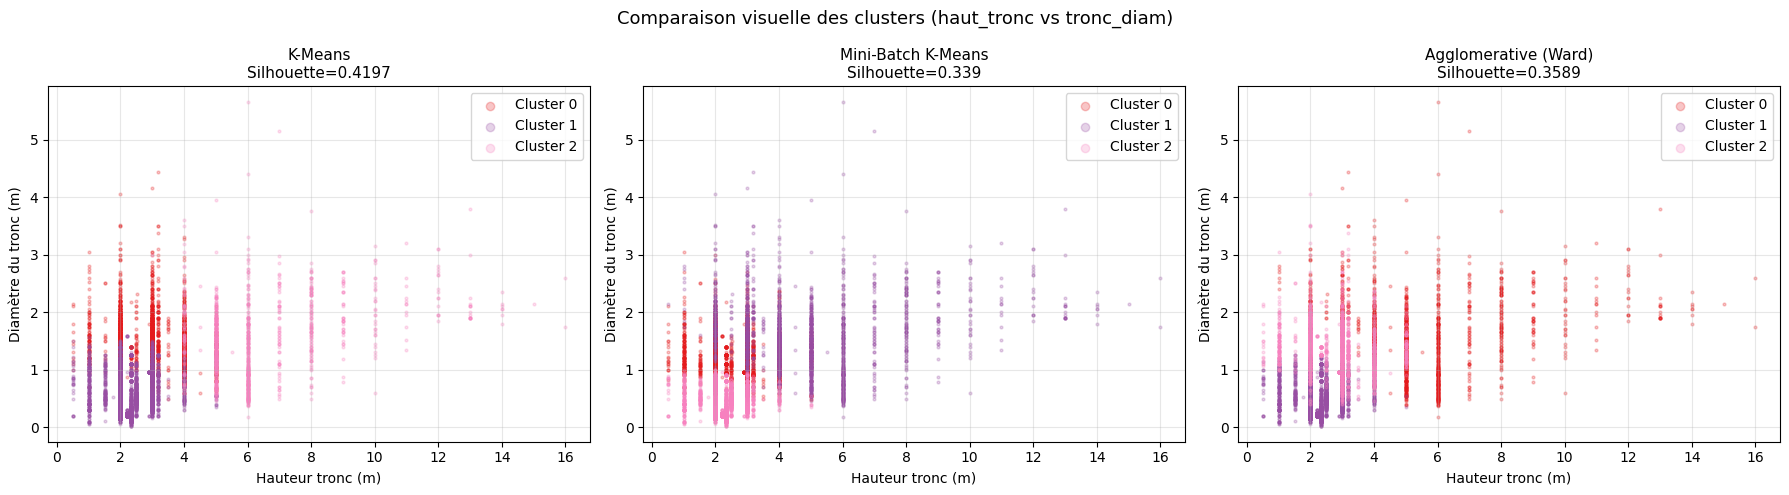

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = plt.cm.Set1(np.linspace(0, 0.8, K_OPTIMAL))

for ax, (name, data) in zip(axes, results.items()):
    labels = data['labels']
    for cluster_id in range(K_OPTIMAL):
        mask = labels == cluster_id
        ax.scatter(
            df_cluster.loc[df_cluster.index[mask], 'haut_tronc'],
            df_cluster.loc[df_cluster.index[mask], 'tronc_diam'],
            alpha=0.25, s=4, color=palette[cluster_id], label=f'Cluster {cluster_id}'
        )
    ax.set_title(f'{name}\nSilhouette={data["Silhouette ↑"]}', fontsize=11)
    ax.set_xlabel('Hauteur tronc (m)')
    ax.set_ylabel('Diamètre du tronc (m)')
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison visuelle des clusters (haut_tronc vs tronc_diam)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{drive_folder_path}clusters_comparaison_visuelle.png', dpi=150)
plt.show()

## 7. Sélection et sauvegarde du meilleur modèle

In [59]:
# Sélection automatique selon le meilleur score Silhouette
best_algo_name = max(
    {k: v for k, v in results.items() if k != 'Agglomerative (Ward)'},
    key=lambda x: results[x]['Silhouette ↑']
)
print(f"Meilleur algorithme sélectionné : {best_algo_name}")
print(f"  (L'Agglomerative est exclu automatiquement car non transductif – ne peut pas prédire sur nouvelles données)")

# Ré-entraînement du meilleur modèle
best_model = algorithms[best_algo_name]
best_labels = best_model.fit_predict(X_scaled)

# Attribution des labels sémantiques (petit/moyen/grand) triés par haut_tot
df_cluster['cluster'] = best_labels
cluster_means = df_cluster.groupby('cluster')[features].mean()
sorted_clusters = cluster_means['haut_tot'].sort_values().index.tolist()

if K_OPTIMAL == 2:
    label_names = ['Petit', 'Grand']
elif K_OPTIMAL == 3:
    label_names = ['Petit', 'Moyen', 'Grand']
else:
    label_names = [f'Groupe {i+1}' for i in range(K_OPTIMAL)]

label_map = {cluster_id: label_names[i] for i, cluster_id in enumerate(sorted_clusters)}
df_cluster['taille_label'] = df_cluster['cluster'].map(label_map)

print(f"\nLabels assignés : {label_map}")
print(df_cluster['taille_label'].value_counts())

Meilleur algorithme sélectionné : K-Means
  (L'Agglomerative est exclu automatiquement car non transductif – ne peut pas prédire sur nouvelles données)

Labels assignés : {1: 'Petit', 0: 'Moyen', 2: 'Grand'}
taille_label
Petit    6711
Moyen    3657
Grand    1050
Name: count, dtype: int64


In [60]:
# Sauvegarde des fichiers nécessaires pour le script final
joblib.dump(best_model,  f'{drive_folder_path}kmeans_model.pkl')
joblib.dump(label_map,   f'{drive_folder_path}kmeans_label_map.pkl')
# Le scaler a déjà été sauvegardé en section 2

print("Fichiers sauvegardés :")
print("  kmeans_model.pkl       → modèle de clustering")
print("  kmeans_label_map.pkl   → correspondance cluster → label sémantique")
print("  scaler_clustering.pkl  → scaler pour normaliser les nouvelles données")

Fichiers sauvegardés :
  kmeans_model.pkl       → modèle de clustering
  kmeans_label_map.pkl   → correspondance cluster → label sémantique
  scaler_clustering.pkl  → scaler pour normaliser les nouvelles données


## 8. Récapitulatif final

In [61]:
print("=" * 55)
print(f"  RÉCAPITULATIF – Besoin Client 1 (k={K_OPTIMAL})")
print("=" * 55)
print(df_results.to_string())
print("=" * 55)
print(f"  Algorithme retenu     : {best_algo_name}")
print(f"  Silhouette Score      : {results[best_algo_name]['Silhouette ↑']}")
print(f"  Calinski-Harabasz     : {results[best_algo_name]['Calinski-Harabasz ↑']}")
print(f"  Davies-Bouldin        : {results[best_algo_name]['Davies-Bouldin ↓']}")
print("=" * 55)

  RÉCAPITULATIF – Besoin Client 1 (k=3)
                      Silhouette ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓  Temps (s)
K-Means                     0.4197              8065.97            1.0888      0.313
Mini-Batch K-Means          0.3390              7659.43            1.0893      0.020
Agglomerative (Ward)        0.3589              7493.28            1.2185      7.114
  Algorithme retenu     : K-Means
  Silhouette Score      : 0.4197
  Calinski-Harabasz     : 8065.97
  Davies-Bouldin        : 1.0888


# Section 9 – Visualisation sur carte (Plotly)

Cette section s'ajoute **après la section 6** (sélection et sauvegarde du meilleur modèle).  
À ce stade, `df_cluster` contient déjà les colonnes `cluster`, `taille_label`, `latitude`, `longitude`.

Carte fixe

In [62]:
# Palette de couleurs par label (adaptée à k=2 ou k=3)
COLOR_MAP = {
    'Petit':  '#2ECC71',   # vert
    'Moyen':  '#F39C12',   # orange
    'Grand':  '#E74C3C',   # rouge
    # Si k=2 :
    # 'Petit': '#2ECC71'
    # 'Grand': '#E74C3C'
}

# Centre de la carte sur Saint-Quentin
CENTER_LAT = df_cluster['Latitude'].mean()
CENTER_LON = df_cluster['Longitude'].mean()

fig = go.Figure()

for label in df_cluster['taille_label'].unique():
    mask = df_cluster['taille_label'] == label
    subset = df_cluster[mask]

    fig.add_trace(go.Scattermap(
        lat=subset['Latitude'],
        lon=subset['Longitude'],
        mode='markers',
        name=f'Arbres {label}s ({mask.sum()})',
        marker=go.scattermap.Marker(
            size=5,
            color=COLOR_MAP.get(label, '#888888'),
            opacity=0.7
        ),
        hovertemplate=(
            f'<b>Taille : {label}</b><br>'
            'Lat: %{lat:.5f}<br>'
            'Lon: %{lon:.5f}<br>'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(text=f'Répartition des arbres par taille – Saint-Quentin (k={K_OPTIMAL})', font_size=15),
    map=dict(
        style='carto-positron',
        center=dict(lat=CENTER_LAT, lon=CENTER_LON),
        zoom=12
    ),
    legend=dict(title='Catégorie de taille', bgcolor='rgba(255,255,255,0.8)'),
    height=650,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()
fig.write_html(f'{drive_folder_path}carte_clusters.html')
print("Carte sauvegardée : carte_clusters.html")

Carte sauvegardée : carte_clusters.html


Section 9 – Préparation d'un script

In [63]:
import joblib
from sklearn.cluster import KMeans

SAVE_DIR = '/content/drive/MyDrive/Projet_base_de_donnée/Projet_BDD-IA-WEB/Visualisation-carte/'

# Entraînement k=2
km_k2 = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
km_k2.fit(X_train)
sorted_c2 = pd.DataFrame(X_scaled).groupby(km_k2.labels_)[0].mean().sort_values().index.tolist()
label_map2 = {sorted_c2[0]: 'Petit', sorted_c2[1]: 'Grand'}

# Entraînement k=3
km_k3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_k3.fit(X_train)
sorted_c3 = pd.DataFrame(X_scaled).groupby(km_k3.labels_)[0].mean().sort_values().index.tolist()
label_map3 = {sorted_c3[0]: 'Petit', sorted_c3[1]: 'Moyen', sorted_c3[2]: 'Grand'}

# Sauvegarde en 2 fichiers
joblib.dump({'scaler': scaler, 'model': km_k2, 'label_map': label_map2}, SAVE_DIR + 'clustering_k2.pkl')
joblib.dump({'scaler': scaler, 'model': km_k3, 'label_map': label_map3}, SAVE_DIR + 'clustering_k3.pkl')

print("Fichiers sauvegardés :")
for f in os.listdir(SAVE_DIR):
    if f.endswith('.pkl'):
        print(f"  - {f}")

ValueError: Grouper and axis must be same length

In [ ]:
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(SAVE_DIR + f)
    print(f"{f} — {size/1024:.1f} Ko")